In [8]:
# ==========================================
# UPLOAD ZIP/CSV DATASET
# ==========================================

import pandas as pd
import zipfile
import os
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Load CSV from ZIP
if file_name.endswith('.zip'):

    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall('dataset')

    csv_file = None

    for root, dirs, files_list in os.walk('dataset'):
        for file in files_list:
            if file.endswith('.csv'):
                csv_file = os.path.join(root, file)
                break

    df = pd.read_csv(csv_file)

# Load direct CSV
elif file_name.endswith('.csv'):
    df = pd.read_csv(file_name)

else:
    raise Exception("Upload CSV or ZIP file")

print("Dataset Loaded Successfully")
print(df.head())

# ==========================================
# SHOW COLUMNS
# ==========================================

print("\nAvailable Columns:\n")
for i, col in enumerate(df.columns):
    print(i, ":", col)

# ==========================================
# ENTER TARGET COLUMN
# ==========================================

target = input("\nEnter target column name exactly as shown above: ")

# Check column exists
if target not in df.columns:
    raise Exception("Column name not found. Check spelling.")

# ==========================================
# DATA CLEANING
# ==========================================

df.dropna(inplace=True)

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# ==========================================
# SPLIT DATA
# ==========================================

from sklearn.model_selection import train_test_split

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("\nModel Performance")

print("MAE :", mean_absolute_error(y_test, predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))

print("R2 Score :", r2_score(y_test, predictions))

# ==========================================
# ACTUAL VS PREDICTED GRAPH
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

Saving archive (1).zip to archive (1) (2).zip
Dataset Loaded Successfully
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46  

Exception: Column name not found. Check spelling.

Upload your CSV or ZIP file


Saving archive (1).zip to archive (1) (3).zip
'archive (1) (3).zip' extracted successfully to 'dataset/'

Dataset Loaded Successfully!

First 5 Rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Shape:
(301, 9)

Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Informat

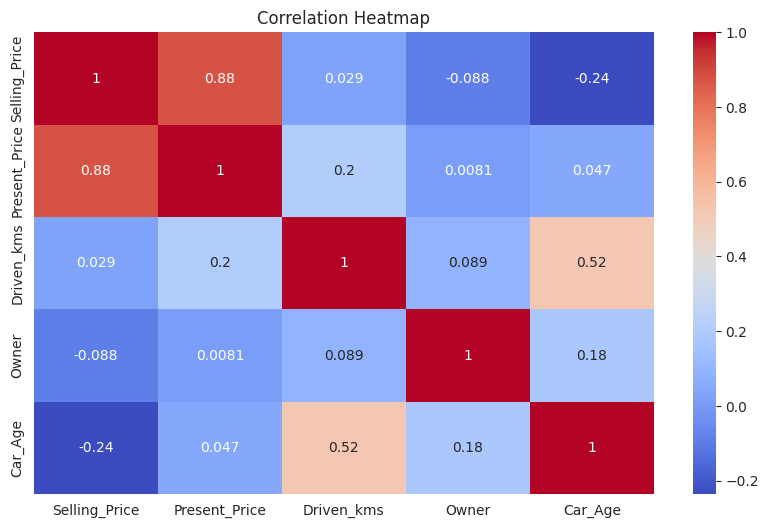

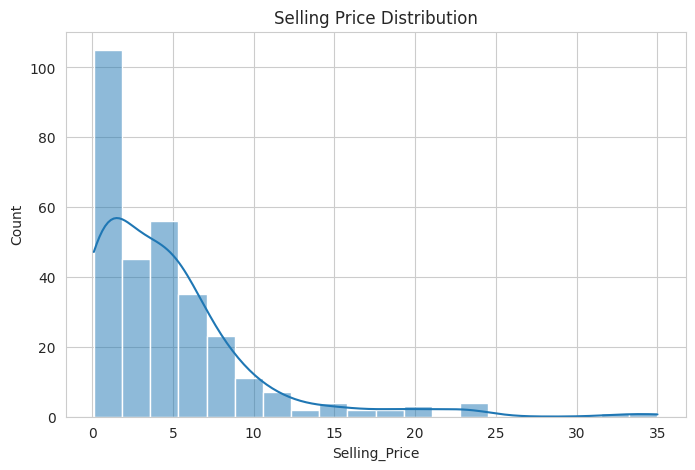


Dataset After Encoding:
   Selling_Price  Present_Price  Driven_kms  Owner  Car_Age  \
0           3.35           5.59       27000      0       12   
1           4.75           9.54       43000      0       13   
2           7.25           9.85        6900      0        9   
3           2.85           4.15        5200      0       15   
4           4.60           6.87       42450      0       12   

   Car_Name_Activa 3g  Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  \
0               False               False                   False   
1               False               False                   False   
2               False               False                   False   
3               False               False                   False   
4               False               False                   False   

   Car_Name_Bajaj Avenger 150  Car_Name_Bajaj Avenger 150 street  ...  \
0                       False                              False  ...   
1                       False      

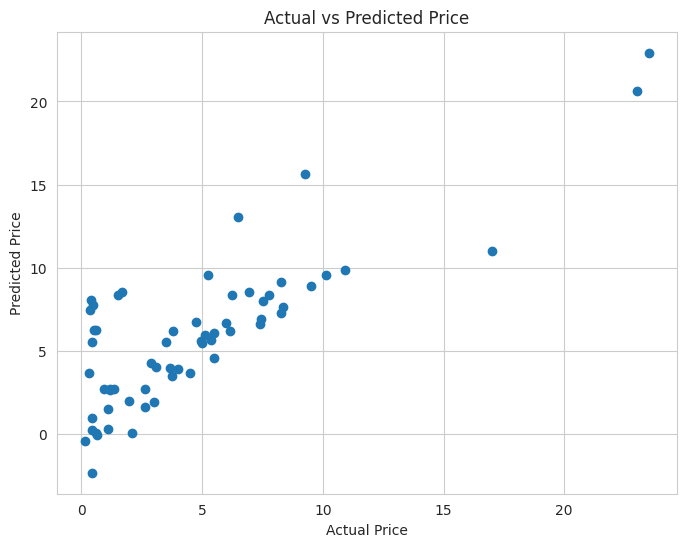

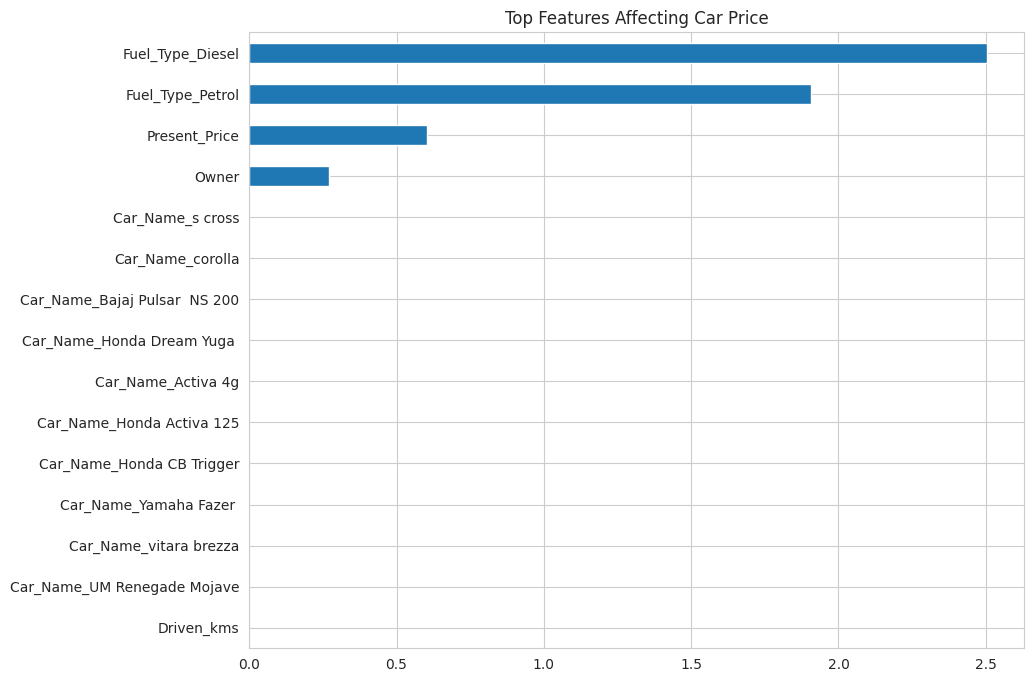


Sample Predictions:
     Actual Price  Predicted Price
177          0.35         7.473271
289         10.11         9.588806
228          4.95         5.568836
198          0.15        -0.409418
60           6.95         8.558960
9            7.45         6.888909
118          1.10         1.476357
154          0.50         6.236953
164          0.45         0.980145
33           6.00         6.689254

========== INSIGHTS ==========
1. Car age significantly affects price.
2. Brand and fuel type influence resale value.
3. Newer cars generally sell at higher prices.
4. The model can estimate selling price using vehicle features.
5. Higher R² indicates better prediction performance.

========== PROJECT COMPLETED ==========


In [9]:
# ==========================================================
# CAR PRICE PREDICTION USING MACHINE LEARNING
# ==========================================================

# Install (if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os
import io # Import io for BytesIO

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# ==========================================================
# UPLOAD DATASET (CSV OR ZIP)
# ==========================================================

print("Upload your CSV or ZIP file")

uploaded = files.upload()

# Get the name of the uploaded file
if not uploaded:
    raise ValueError("No file was uploaded. Please upload a CSV or ZIP file.")

file_name = list(uploaded.keys())[0]
extracted_dir = "dataset"
csv_to_load = None

# ZIP FILE handling
if file_name.endswith(".zip"):
    # Ensure the target directory exists
    os.makedirs(extracted_dir, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(uploaded[file_name]), 'r') as zip_ref:
        zip_ref.extractall(extracted_dir)
    print(f"'{file_name}' extracted successfully to '{extracted_dir}/'")

    # Search for the correct CSV file for car data prediction
    car_data_csv_found = False
    for root, dirs, files_list in os.walk(extracted_dir):
        if "car data.csv" in files_list:
            csv_to_load = os.path.join(root, "car data.csv")
            car_data_csv_found = True
            break
        elif "Car data.csv" in files_list: # Check for alternative casing
            csv_to_load = os.path.join(root, "Car data.csv")
            car_data_csv_found = True
            break

    if not car_data_csv_found:
        # Fallback: if 'car data.csv' not found, take the first CSV
        print(f"Warning: Specific 'car data.csv' or 'Car data.csv' not found in '{extracted_dir}'. Attempting to load the first CSV found.")
        for root, dirs, files_list in os.walk(extracted_dir):
            for file in files_list:
                if file.endswith(".csv"):
                    csv_to_load = os.path.join(root, file)
                    print(f"Using '{csv_to_load}' as the dataset.")
                    break
            if csv_to_load:
                break
    if csv_to_load is None:
        raise ValueError("No CSV file found within the uploaded zip archive.")

# CSV FILE handling
elif file_name.endswith(".csv"):
    # If a single CSV is uploaded, it's directly available
    csv_to_load = file_name
    print(f"'{file_name}' uploaded directly.")

else:
    raise ValueError("Please upload a CSV or ZIP file.")

if csv_to_load and os.path.exists(csv_to_load):
    df = pd.read_csv(csv_to_load)
else:
    raise FileNotFoundError(f"Failed to find or load the CSV file: {csv_to_load}")

print("\nDataset Loaded Successfully!")

# ==========================================================
# DATA OVERVIEW
# ==========================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================================
# DATA CLEANING
# ==========================================================

df.columns = df.columns.str.strip()

df.dropna(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

if 'Year' in df.columns:
    df['Car_Age'] = 2026 - df['Year']
    df.drop('Year', axis=1, inplace=True)

# ==========================================================
# VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# SELLING PRICE DISTRIBUTION
# ==========================================================

if 'Selling_Price' in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(df['Selling_Price'],
                 bins=20,
                 kde=True)

    plt.title("Selling Price Distribution")
    plt.show()

# ==========================================================
# ENCODING CATEGORICAL COLUMNS
# ==========================================================

categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df,
                    columns=categorical_cols,
                    drop_first=True)

print("\nDataset After Encoding:")
print(df.head())

# ==========================================================
# DEFINE TARGET VARIABLE
# ==========================================================

possible_targets = [
    'Selling_Price',
    'selling_price',
    'Price',
    'price'
]

target = None

for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    print("\nAvailable Columns:")
    print(df.columns)
    raise Exception("Target column not found.")

X = df.drop(target, axis=1)

y = df[target]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==========================================================
# TRAIN MODEL
# ==========================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")

# ==========================================================
# PREDICTION
# ==========================================================

predictions = model.predict(X_test)

# ==========================================================
# EVALUATION
# ==========================================================

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\n========== MODEL PERFORMANCE ==========")

print("Mean Absolute Error :", round(mae, 2))

print("Mean Squared Error :", round(mse, 2))

print("Root Mean Squared Error :", round(rmse, 2))

print("R2 Score :", round(r2, 4))

# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test,
            predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.Series(
    model.coef_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(10,8))

importance.tail(15).plot(
    kind='barh'
)

plt.title("Top Features Affecting Car Price")

plt.show()

# ==========================================================
# PREDICTION TABLE
# ==========================================================

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

print("\nSample Predictions:")

print(results.head(10))

# ==========================================================
# INSIGHTS
# ==========================================================

print("\n========== INSIGHTS ==========")

print("1. Car age significantly affects price.")
print("2. Brand and fuel type influence resale value.")
print("3. Newer cars generally sell at higher prices.")
print("4. The model can estimate selling price using vehicle features.")
print("5. Higher R² indicates better prediction performance.")

print("\n========== PROJECT COMPLETED ==========")